# Week 1 — Introduction to Forecasting

This notebook introduces the core ideas of economic and business forecasting: what forecasting is, why it matters for policy and business, and the key properties of time series data — trend, seasonality, cycles, and stationarity.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Edinburgh palette
UOE_RED   = '#7A2318'
UOE_GOLD  = '#B8860B'
UOE_BLUE  = '#2a78d6'
UOE_GREY  = '#52514e'
COLOURS   = [UOE_RED, UOE_BLUE, UOE_GOLD, '#2ca02c', '#9467bd', '#e377c2']

mpl.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.prop_cycle': mpl.cycler(color=COLOURS),
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 12, 'axes.titlesize': 14,
    'font.size': 11, 'legend.fontsize': 10,
    'lines.linewidth': 2,
})
print("Plotting style set ✓")


Plotting style set ✓


## 1.1 What Is Forecasting?

Forecasting is the process of making predictions about future values of a variable based on its past behaviour and possibly other information. In economics and business, good forecasts underpin monetary policy, fiscal planning, inventory management, and financial risk assessment.

**Key question:** given observations $y_1, y_2, \dots, y_T$, what is our best prediction of $y_{T+h}$ for horizon $h \geq 1$?

## 1.2 Simulating a Time Series with Trend, Seasonality, and Noise

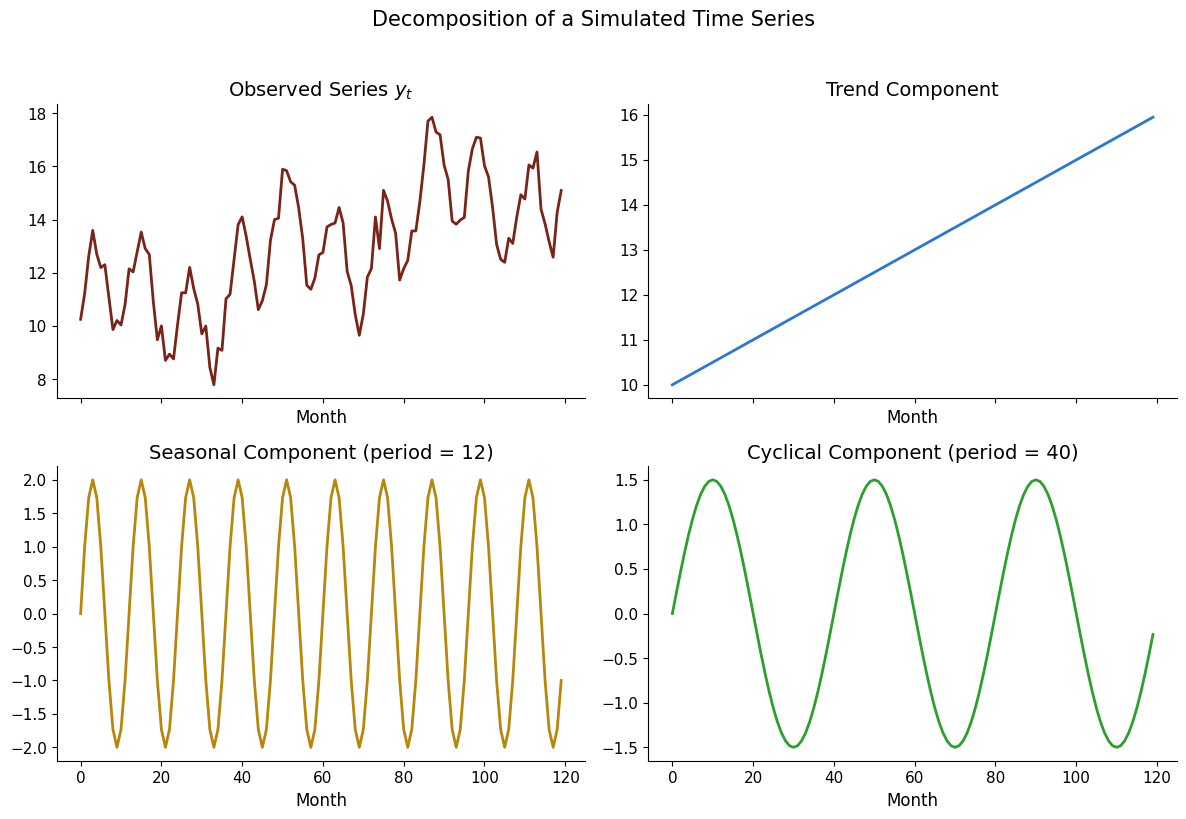

In [2]:
np.random.seed(42)
T = 120  # 10 years of monthly data
t = np.arange(T)

# Components
trend = 0.05 * t
seasonal = 2 * np.sin(2 * np.pi * t / 12)
cycle = 1.5 * np.sin(2 * np.pi * t / 40)
noise = np.random.normal(0, 0.5, T)
y = 10 + trend + seasonal + cycle + noise

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

axes[0, 0].plot(t, y, color=UOE_RED)
axes[0, 0].set_title('Observed Series $y_t$')

axes[0, 1].plot(t, 10 + trend, color=UOE_BLUE)
axes[0, 1].set_title('Trend Component')

axes[1, 0].plot(t, seasonal, color=UOE_GOLD)
axes[1, 0].set_title('Seasonal Component (period = 12)')

axes[1, 1].plot(t, cycle, color='#2ca02c')
axes[1, 1].set_title('Cyclical Component (period = 40)')

for ax in axes.flat:
    ax.set_xlabel('Month')
plt.suptitle('Decomposition of a Simulated Time Series', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


## 1.3 Stationarity

A time series $\{y_t\}$ is **covariance stationary** if:

1. $E[y_t] = \mu$ for all $t$ (constant mean)
2. $\text{Var}(y_t) = \sigma^2$ for all $t$ (constant variance)
3. $\text{Cov}(y_t, y_{t-k}) = \gamma_k$ depends only on $k$, not $t$

Most forecasting models require stationarity — or at least that we can transform the data to achieve it (e.g. differencing).

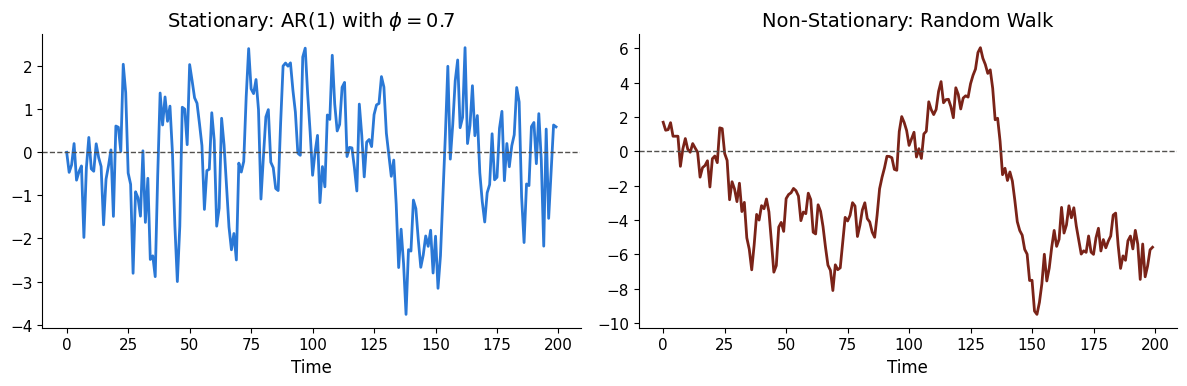

In [3]:
# Stationary vs non-stationary series
np.random.seed(7)
eps = np.random.normal(0, 1, 200)

# Stationary: AR(1) with |phi| < 1
y_stat = np.zeros(200)
for i in range(1, 200):
    y_stat[i] = 0.7 * y_stat[i-1] + eps[i]

# Non-stationary: random walk
y_rw = np.cumsum(eps)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(y_stat, color=UOE_BLUE)
ax1.axhline(0, ls='--', color=UOE_GREY, lw=1)
ax1.set_title('Stationary: AR(1) with $\\phi = 0.7$')
ax1.set_xlabel('Time')

ax2.plot(y_rw, color=UOE_RED)
ax2.axhline(0, ls='--', color=UOE_GREY, lw=1)
ax2.set_title('Non-Stationary: Random Walk')
ax2.set_xlabel('Time')
plt.tight_layout()
plt.show()


## 1.4 Autocorrelation Function (ACF)

The ACF measures how correlated $y_t$ is with its own past values:

$$\rho_k = \frac{\gamma_k}{\gamma_0} = \frac{\text{Cov}(y_t, y_{t-k})}{\text{Var}(y_t)}$$

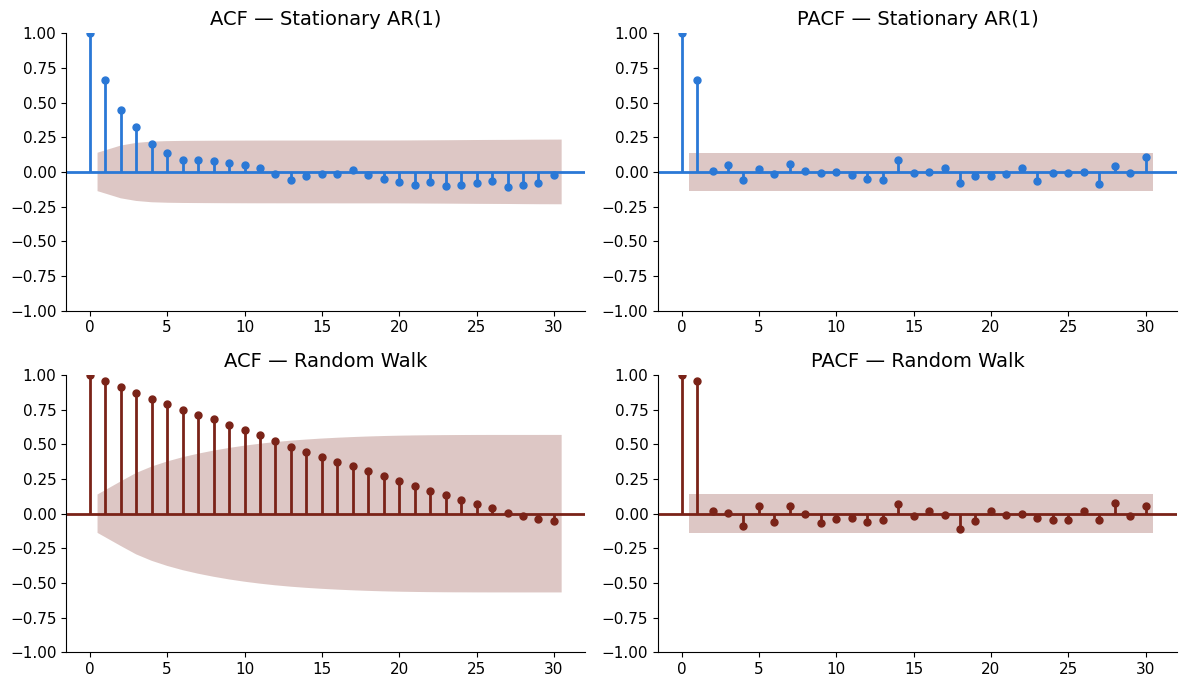

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

plot_acf(y_stat, lags=30, ax=axes[0, 0], color=UOE_BLUE,
         vlines_kwargs={'color': UOE_BLUE})
axes[0, 0].set_title('ACF — Stationary AR(1)')

plot_pacf(y_stat, lags=30, ax=axes[0, 1], color=UOE_BLUE,
          vlines_kwargs={'color': UOE_BLUE})
axes[0, 1].set_title('PACF — Stationary AR(1)')

plot_acf(y_rw, lags=30, ax=axes[1, 0], color=UOE_RED,
         vlines_kwargs={'color': UOE_RED})
axes[1, 0].set_title('ACF — Random Walk')

plot_pacf(y_rw, lags=30, ax=axes[1, 1], color=UOE_RED,
          vlines_kwargs={'color': UOE_RED})
axes[1, 1].set_title('PACF — Random Walk')

plt.tight_layout()
plt.show()


## 1.5 A First Forecast: the Naive Method

The simplest forecast: $\hat{y}_{T+h|T} = y_T$ (last observed value). Despite its simplicity, it is hard to beat for random walks.

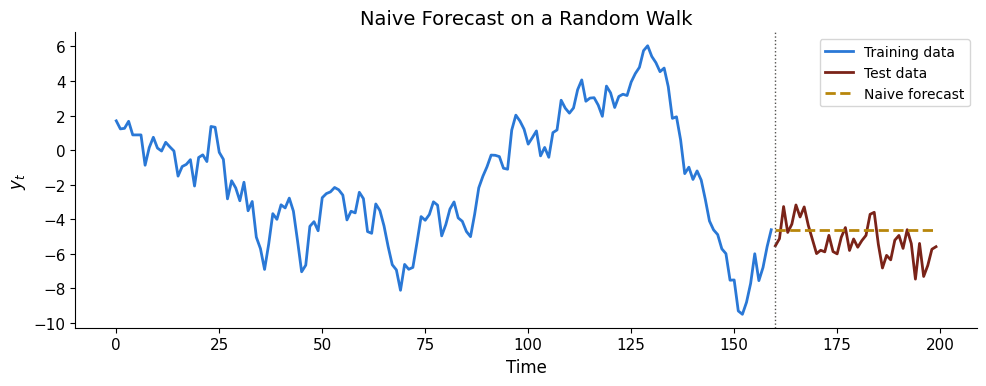

Naive forecast RMSE: 1.198


In [5]:
# Naive forecast on the random walk
train, test = y_rw[:160], y_rw[160:]
naive_fc = np.full(len(test), train[-1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(160), train, color=UOE_BLUE, label='Training data')
ax.plot(range(160, 200), test, color=UOE_RED, label='Test data')
ax.plot(range(160, 200), naive_fc, '--', color=UOE_GOLD, lw=2, label='Naive forecast')
ax.axvline(160, ls=':', color=UOE_GREY, lw=1)
ax.set_xlabel('Time')
ax.set_ylabel('$y_t$')
ax.set_title('Naive Forecast on a Random Walk')
ax.legend()
plt.tight_layout()
plt.show()

rmse = np.sqrt(np.mean((test - naive_fc)**2))
print(f"Naive forecast RMSE: {rmse:.3f}")


## Exercises

<details><summary>Exercise 1: Generate a seasonal random walk and plot its ACF.</summary>

```python
np.random.seed(10)
T = 240
y = np.zeros(T)
for i in range(12, T):
    y[i] = y[i-12] + np.random.normal(0, 1)
fig, ax = plt.subplots()
plot_acf(y, lags=50, ax=ax)
plt.show()
```
</details>